# Final Project

## 1. Scope the Project

Our plan is to use a supervised learning technique to predict which customers are most likely to cancel their subscription using **the past three months of customer data which includes subscription and listening history**.

## 2. Gather Data

Read the following files into Python:
* Customer data: *maven_music_customers.csv*
* Listing history: *maven_music_listening_history.xlsx*

In [318]:
# Read in the customer data
import pandas as pd
customer_data = pd.read_csv("../Data/maven_music_customers.csv")
customer_data.head(3)
customer_data.shape

(30, 8)

In [319]:
# Read in the listening history
listening_data = pd.read_excel("../Data/maven_music_listening_history.xlsx")
listening_data.head(3)

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type
0,5001,100520,1,101,Song
1,5001,100520,2,102,Song
2,5001,100520,3,103,Song


In [320]:
# Hint: Where might you find listening history data beyond the ID's?


In [321]:
# Read in the audio data
audio_data = pd.read_excel("../Data/maven_music_listening_history.xlsx", sheet_name=1)
audio_data.head(3)

,ID,Name,Genre,Popularity
0,Song-101,Dance All Night,Pop,1
1,Song-102,Unbreakable Beat,Pop,2
2,Song-103,Sunset Boulevard,Pop Music,5


In [322]:
# Read in the session data
session_data = pd.read_excel("../Data/maven_music_listening_history.xlsx", sheet_name=2)
session_data.head(3)


,Session ID,Session Log In Time
0,100520,2023-03-13 18:29:00
1,100522,2023-03-13 22:15:00
2,100525,2023-03-14 10:01:00


## 3. Clean Data

### a. Convert Data Types

Check the data types of the data in the tables and convert to numeric and datetime values as necessary.

In [323]:
# Check the data types
customer_data.dtypes

Customer ID           int64
Customer Name        object
Email                object
Member Since         object
Subscription Plan    object
Subscription Rate    object
Discount?            object
Cancellation Date    object
dtype: object

In [324]:
listening_data.dtypes

Customer ID     int64
Session ID      int64
Audio Order     int64
Audio ID        int64
Audio Type     object
dtype: object

In [325]:
audio_data.dtypes

ID            object
Name          object
Genre         object
Popularity     int64
dtype: object

In [326]:
session_data.dtypes

Session ID                      int64
Session Log In Time    datetime64[ns]
dtype: object

In [327]:
customer_data["Member Since"] = pd.to_datetime(customer_data["Member Since"])
customer_data["Cancellation Date"] = pd.to_datetime(customer_data["Cancellation Date"])
customer_data["Subscription Rate"] = pd.to_numeric(customer_data["Subscription Rate"].str.strip("$"))
customer_data.dtypes

C:\Users\Eli\AppData\Local\Temp\ipykernel_10248\659049740.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  customer_data["Member Since"] = pd.to_datetime(customer_data["Member Since"])
C:\Users\Eli\AppData\Local\Temp\ipykernel_10248\659049740.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  customer_data["Cancellation Date"] = pd.to_datetime(customer_data["Cancellation Date"])


Customer ID                   int64
Customer Name                object
Email                        object
Member Since         datetime64[ns]
Subscription Plan            object
Subscription Rate           float64
Discount?                    object
Cancellation Date    datetime64[ns]
dtype: object

### b. Resolve Data Issues

Check for missing data, inconsistent text and typos, duplicate data and outliers.

#### i. Missing Data

In [328]:
# Look for NaN values in the data
import numpy as np
customer_data[customer_data.isna().any(axis=1)]
customer_data["Subscription Plan"] = np.where(customer_data["Subscription Rate"]==2.99,"Basic (Ads)",customer_data["Subscription Plan"])
customer_data["Discount?"] = customer_data["Discount?"].fillna("No")
customer_data["Cancellation Date"] = customer_data["Cancellation Date"].fillna(pd.to_datetime(12-12-99))
customer_data[customer_data.isna().any(axis=1)]

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date


#### ii. Inconsistent Text & Typos

In [329]:
# Look for inconsistent text & typo
customer_data["Subscription Plan"].value_counts()

Subscription Plan
Basic (Ads)         17
Premium (No Ads)    13
Name: count, dtype: int64

In [330]:
customer_data["Email"] = customer_data["Email"].str[7:]
customer_data["Subscription Plan"] = customer_data["Subscription Plan"].str.split(" ").str[0]
audio_data["ID"] = audio_data["ID"].str.split("-").str[1]
audio_data["ID"]=pd.to_numeric(audio_data["ID"])

In [331]:
audio_data.dtypes

ID             int64
Name          object
Genre         object
Popularity     int64
dtype: object

In [332]:
customer_data

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,harmonious.vibes@email.com,2023-03-13,Basic,2.99,No,1969-12-31 23:59:59.999999901
1,5002,Aria Keys,melodious.aria@email.edu,2023-03-13,Basic,2.99,No,1969-12-31 23:59:59.999999901
2,5004,Lyric Bell,rhythmical.lyric@email.com,2023-03-13,Basic,2.99,No,2023-06-01 00:00:00.000000000
3,5267,Rock Bassett,groovy.rock@email.com,2023-03-20,Basic,2.99,No,1969-12-31 23:59:59.999999901
4,5338,Rhythm Dixon,beats.by.rhythm@email.edu,2023-03-20,Basic,2.99,No,1969-12-31 23:59:59.999999901
5,5404,Jazz Saxton,jazzy.sax@email.com,2023-03-20,Basic,2.99,No,2023-06-03 00:00:00.000000000
6,5581,Reed Sharp,sharp.tunes@email.com,2023-03-21,Premium,9.99,No,1969-12-31 23:59:59.999999901
7,5759,Carol Kingbird,songbird.carol@email.com,2023-03-22,Premium,9.99,No,2023-06-02 00:00:00.000000000
8,5761,Sonata Nash,musical.sonata@email.com,2023-03-28,Premium,9.99,No,1969-12-31 23:59:59.999999901
9,5763,Jazz Coleman,coleman.jazzmaster@email.com,2023-03-28,Basic,2.99,No,1969-12-31 23:59:59.999999901


#### iii. Duplicate Rows

In [333]:
# Look for duplicate rows


In [334]:
listening_data.duplicated().value_counts()

False    505
Name: count, dtype: int64

#### iv. Outliers

C:\Users\Eli\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Eli\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


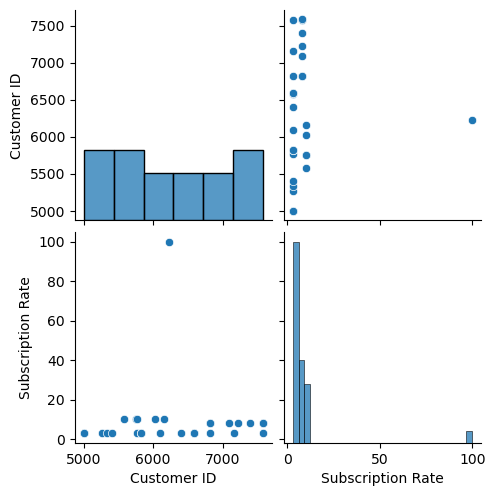

In [335]:
# Look for outliers
import seaborn as sns
sns.pairplot(customer_data)


In [336]:
customer_data[customer_data["Subscription Rate"]>80]

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
15,6229,Symphony Rhodes,rhodes.symphony@email.com,2023-04-06,Premium,99.99,No,2023-06-02


In [337]:
customer_data.iloc[15, 5] = 9.99

In [338]:
customer_data[customer_data["Subscription Rate"]>80]

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date


C:\Users\Eli\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Eli\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Eli\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Eli\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead

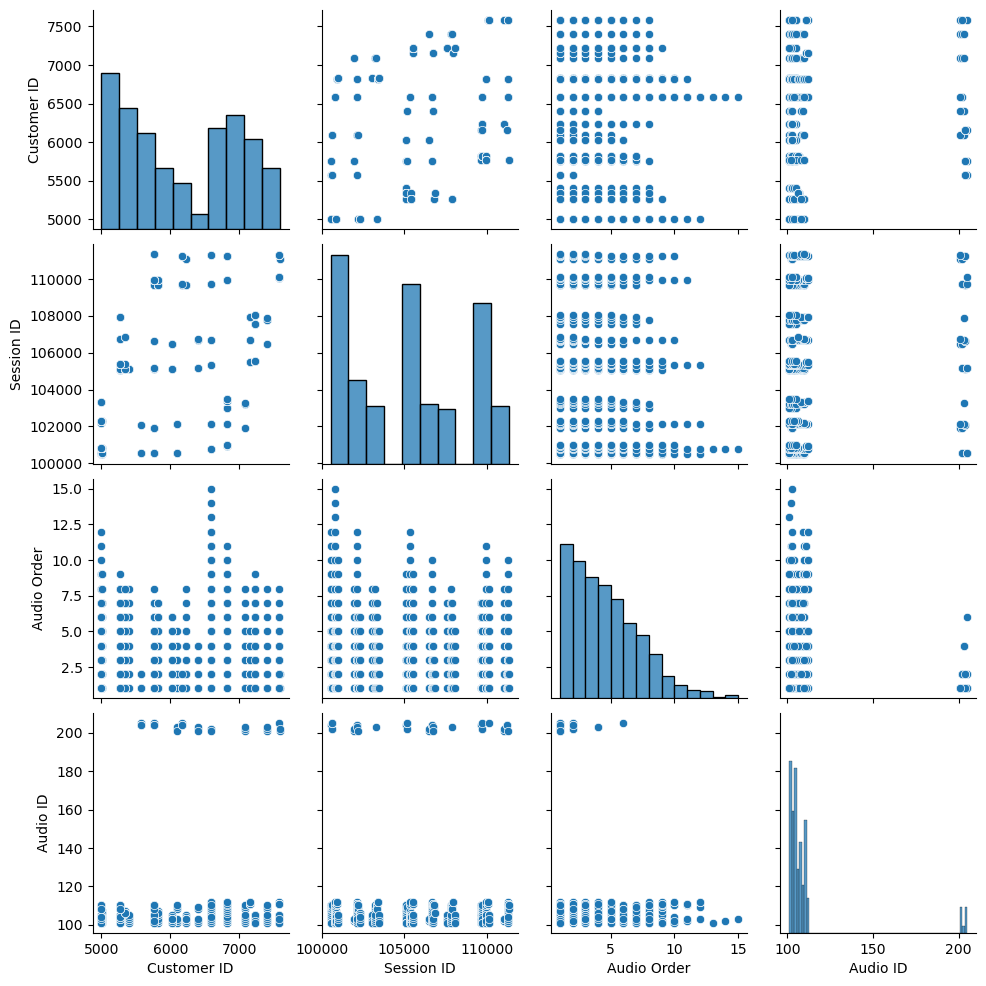

In [339]:
sns.pairplot(listening_data)

### c. Create New Columns

Create two new columns that will be useful for EDA and modeling:
* Cancelled: whether a customer cancelled or not
* Email: Remove the "Email:" from the email addresses

In [340]:
# Create a 'Cancelled' column
customer_data[customer_data["Cancellation Date"]>pd.to_datetime('2023-01-01')]
customer_data["Cancelled"] = np.where(customer_data["Cancellation Date"]>pd.to_datetime('2023-01-01'), "Yes", "No")
customer_data

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date,Cancelled
0,5001,Harmony Greene,harmonious.vibes@email.com,2023-03-13,Basic,2.99,No,1969-12-31 23:59:59.999999901,No
1,5002,Aria Keys,melodious.aria@email.edu,2023-03-13,Basic,2.99,No,1969-12-31 23:59:59.999999901,No
2,5004,Lyric Bell,rhythmical.lyric@email.com,2023-03-13,Basic,2.99,No,2023-06-01 00:00:00.000000000,Yes
3,5267,Rock Bassett,groovy.rock@email.com,2023-03-20,Basic,2.99,No,1969-12-31 23:59:59.999999901,No
4,5338,Rhythm Dixon,beats.by.rhythm@email.edu,2023-03-20,Basic,2.99,No,1969-12-31 23:59:59.999999901,No
5,5404,Jazz Saxton,jazzy.sax@email.com,2023-03-20,Basic,2.99,No,2023-06-03 00:00:00.000000000,Yes
6,5581,Reed Sharp,sharp.tunes@email.com,2023-03-21,Premium,9.99,No,1969-12-31 23:59:59.999999901,No
7,5759,Carol Kingbird,songbird.carol@email.com,2023-03-22,Premium,9.99,No,2023-06-02 00:00:00.000000000,Yes
8,5761,Sonata Nash,musical.sonata@email.com,2023-03-28,Premium,9.99,No,1969-12-31 23:59:59.999999901,No
9,5763,Jazz Coleman,coleman.jazzmaster@email.com,2023-03-28,Basic,2.99,No,1969-12-31 23:59:59.999999901,No


In [341]:
# Create an updated 'Email' column without the Email: portion


 Already Did this

## 4. EDA

Try to better understand the customers who cancelled:
* How long were they members before they cancelled?
* What percentage of customers who cancelled had a discount vs customers who didn't cancel?

In [342]:
# How long were customers members before they cancelled?
np.where(((customer_data["Cancellation Date"]-customer_data["Member Since"]).dt.days>0), (customer_data["Cancellation Date"]-customer_data["Member Since"]).dt.days, 0)

array([ 0,  0, 80,  0,  0, 75,  0, 72,  0,  0,  0,  0, 65, 61,  0, 57,  0,
        0,  0, 46,  0,  0, 32, 32,  0, 24, 24,  0, 18, 16], dtype=int64)

In [343]:
# Cancellation rate for those who had a discount
customer_data.dtypes

Customer ID                   int64
Customer Name                object
Email                        object
Member Since         datetime64[ns]
Subscription Plan            object
Subscription Rate           float64
Discount?                    object
Cancellation Date    datetime64[ns]
Cancelled                    object
dtype: object

In [344]:
customer_data

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date,Cancelled
0,5001,Harmony Greene,harmonious.vibes@email.com,2023-03-13,Basic,2.99,No,1969-12-31 23:59:59.999999901,No
1,5002,Aria Keys,melodious.aria@email.edu,2023-03-13,Basic,2.99,No,1969-12-31 23:59:59.999999901,No
2,5004,Lyric Bell,rhythmical.lyric@email.com,2023-03-13,Basic,2.99,No,2023-06-01 00:00:00.000000000,Yes
3,5267,Rock Bassett,groovy.rock@email.com,2023-03-20,Basic,2.99,No,1969-12-31 23:59:59.999999901,No
4,5338,Rhythm Dixon,beats.by.rhythm@email.edu,2023-03-20,Basic,2.99,No,1969-12-31 23:59:59.999999901,No
5,5404,Jazz Saxton,jazzy.sax@email.com,2023-03-20,Basic,2.99,No,2023-06-03 00:00:00.000000000,Yes
6,5581,Reed Sharp,sharp.tunes@email.com,2023-03-21,Premium,9.99,No,1969-12-31 23:59:59.999999901,No
7,5759,Carol Kingbird,songbird.carol@email.com,2023-03-22,Premium,9.99,No,2023-06-02 00:00:00.000000000,Yes
8,5761,Sonata Nash,musical.sonata@email.com,2023-03-28,Premium,9.99,No,1969-12-31 23:59:59.999999901,No
9,5763,Jazz Coleman,coleman.jazzmaster@email.com,2023-03-28,Basic,2.99,No,1969-12-31 23:59:59.999999901,No


In [413]:
cancellation_rate[2]

C:\Users\Eli\AppData\Local\Temp\ipykernel_10248\3068436253.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cancellation_rate[2]


1

In [414]:
# Cancellation rate for those who did not have a discount
cancellation_rate = customer_data.groupby(["Discount?","Cancelled"])["Cancelled"].count()
cancellation_rate = pd.DataFrame(cancellation_rate)
cancelled_w_discount = np.round((cancellation_rate[1,0]/(cancellation_rate.iloc[0,0]+cancellation_rate.iloc[1,0])),3)
cancelled_w_discount

KeyError: (1, 0)

<Axes: >

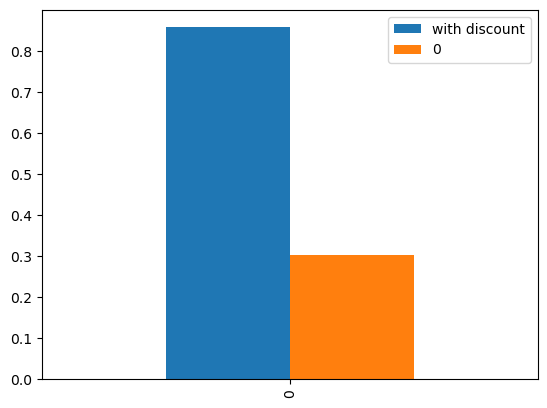

In [346]:
# Visualize the cancellation rate for those with a discount vs those without a discount
cancelled_wo_discount=np.round((cancellation_rate.iloc[3,0]/(cancellation_rate.iloc[2,0]+cancellation_rate.iloc[3,0])),3)
comparision_of_cancellations = pd.DataFrame([cancelled_w_discount], [cancelled_wo_discount]).reset_index()
comparision_of_cancellations = comparision_of_cancellations.rename(columns={'index':'with discount','0 ':'without discount'})
comparision_of_cancellations.plot.bar()

Better understand the customers' listening histories:
* Join together the listening history and audio tables
* How many listening sessions did each customer have in the past 3 months?
* What were the most popular genres that customers listened to?

In [347]:
sessions_last_3_months = session_data[(session_data["Session Log In Time"].max()-session_data["Session Log In Time"]).dt.days<90]

In [348]:
# The number of listening sessions that each customer had in the past 3 months
number_of_sessions = listening_data[["Customer ID", "Session ID"]].drop_duplicates().merge(sessions_last_3_months).groupby("Customer ID")["Session ID"].count().reset_index()
number_of_sessions = number_of_sessions.rename(columns={"Session ID":"Number of Sessions"})

In [349]:
# The most popular genres that customers listened to
audio_data = audio_data.rename(columns={"ID":"Audio ID"})
popular_genre = listening_data[["Customer ID", "Session ID", "Audio ID"]].merge(audio_data[["Audio ID", "Genre"]])
popular_genre.groupby("Genre").count().reset_index()

,Genre,Customer ID,Session ID,Audio ID
0,Comedy,19,19,19
1,Country,68,68,68
2,Hip Hop,88,88,88
3,Jazz,48,48,48
4,Pop,100,100,100
5,Pop Music,167,167,167
6,True Crime,15,15,15


## 5. Prep for Modeling

Create a DataFrame that is ready for modeling with each row representing a customer and the following numeric, non-null columns:
* Customer ID
* Whether a customer cancelled or not
* Whether a customer received a discount or not
* The number of listening sessions
* Percent of listening history consisting of Pop
* Percent of listening history consisting of Podcasts

In [368]:
# Create a dataframe ready for modeling
aggregate_data = customer_data[["Customer ID","Cancelled","Discount?"]].copy()
aggregate_data["Cancelled"] = pd.get_dummies(aggregate_data["Cancelled"])["Yes"]
aggregate_data["Discount?"] = pd.get_dummies(aggregate_data["Discount?"])["Yes"]
aggregate_data

,Customer ID,Cancelled,Discount?
0,5001,False,False
1,5002,False,False
2,5004,True,False
3,5267,False,False
4,5338,False,False
5,5404,True,False
6,5581,False,False
7,5759,True,False
8,5761,False,False
9,5763,False,False


In [369]:
# Calculate the number of listening sessions for each customer
aggregate_data = aggregate_data.merge(number_of_sessions)

In [370]:
# Percent pop
popular_genre["Pop"] = np.where(popular_genre["Genre"].str.contains("Pop"), 1,0)
pop = pd.DataFrame(popular_genre.groupby(["Customer ID"])["Pop"].sum())
total = pd.DataFrame(popular_genre.groupby(["Customer ID"])["Genre"].count())
percent = (pop.Pop/total.Genre).round(2).reset_index()
aggregate_data = aggregate_data.merge(percent)
aggregate_data = aggregate_data.rename(columns={0: '% Pop'})

In [371]:
aggregate_data

,Customer ID,Cancelled,Discount?,Number of Sessions,% Pop
0,5001,False,False,8,0.57
1,5002,False,False,4,0.00
2,5004,True,False,1,1.00
3,5267,False,False,7,0.51
4,5338,False,False,4,0.00
5,5404,True,False,1,1.00
6,5581,False,False,3,0.00
7,5759,True,False,2,1.00
8,5761,False,False,3,0.00
9,5763,False,False,6,0.65


In [415]:
total

,Genre
Customer ID,
5001,60
5002,22
5004,9
5267,45
5338,18
5404,8
5581,5
5759,15
5761,5


In [372]:
# Percent podcasts
popular_genre["True Crime"] = np.where(popular_genre["Genre"].str.contains("True Crime"), 1,0)
podcasts = pd.DataFrame(popular_genre.groupby(["Customer ID"])["True Crime"].sum())
total = pd.DataFrame(popular_genre.groupby(["Customer ID"])["Genre"].count())
percent = (podcasts["True Crime"]/total.Genre).round(2).reset_index()
aggregate_data = aggregate_data.merge(percent, how="left")
aggregate_data = aggregate_data.rename(columns={0: '% Podcast'})


,Customer ID,Cancelled,Discount?,Number of Sessions,% Pop,% Podcast
2,5004,True,False,1,1.00,0.00
5,5404,True,False,1,1.00,0.00
7,5759,True,False,2,1.00,0.00
12,6029,True,False,2,1.00,0.00
13,6092,True,False,3,0.30,0.00
15,6229,True,False,2,1.00,0.00
19,6588,True,False,3,0.40,0.00
22,6824,True,True,4,1.00,0.00
23,7087,True,True,3,0.45,0.00
25,7224,True,True,4,1.00,0.00


Visualize the relationships in the modeling DataFrame using a pair plot:
* What are some of your observations?
* What variables might do a good job predicting customer cancellation?

# It looks like the number of sessions and if they listen to pop music will be good predictors, but listening to podcasts is not

In [373]:
aggregate_data

,Customer ID,Cancelled,Discount?,Number of Sessions,% Pop,% Podcast
0,5001,False,False,8,0.57,0.00
1,5002,False,False,4,0.00,0.00
2,5004,True,False,1,1.00,0.00
3,5267,False,False,7,0.51,0.00
4,5338,False,False,4,0.00,0.00
5,5404,True,False,1,1.00,0.00
6,5581,False,False,3,0.00,1.00
7,5759,True,False,2,1.00,0.00
8,5761,False,False,3,0.00,1.00
9,5763,False,False,6,0.65,0.00


In [416]:
aggregate_data.corr()

,Customer ID,Cancelled,Discount?,Number of Sessions,% Pop,% Podcast
Customer ID,1.000000,0.269942,0.648514,-0.337083,-0.077422,-0.171377
Cancelled,0.269942,1.000000,0.471825,-0.333739,0.584480,-0.283083
Discount?,0.648514,0.471825,1.000000,-0.048877,0.111384,-0.170086
Number of Sessions,-0.337083,-0.333739,-0.048877,1.000000,-0.129659,-0.004832
% Pop,-0.077422,0.584480,0.111384,-0.129659,1.000000,-0.381877
% Podcast,-0.171377,-0.283083,-0.170086,-0.004832,-0.381877,1.000000
